# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

from utils import plot_pdf, symmetrical_polynomial_factorization

In [3]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This example will not work for different vector sizes.

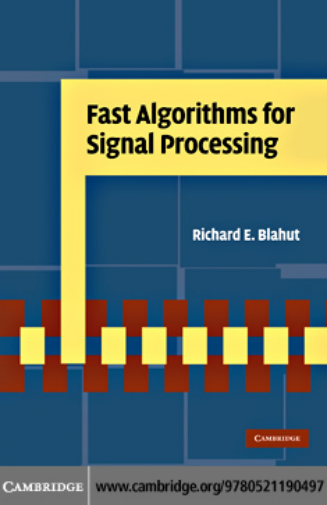

In [4]:
plot_pdf(doc[0], dpi=100)

## Polynomials

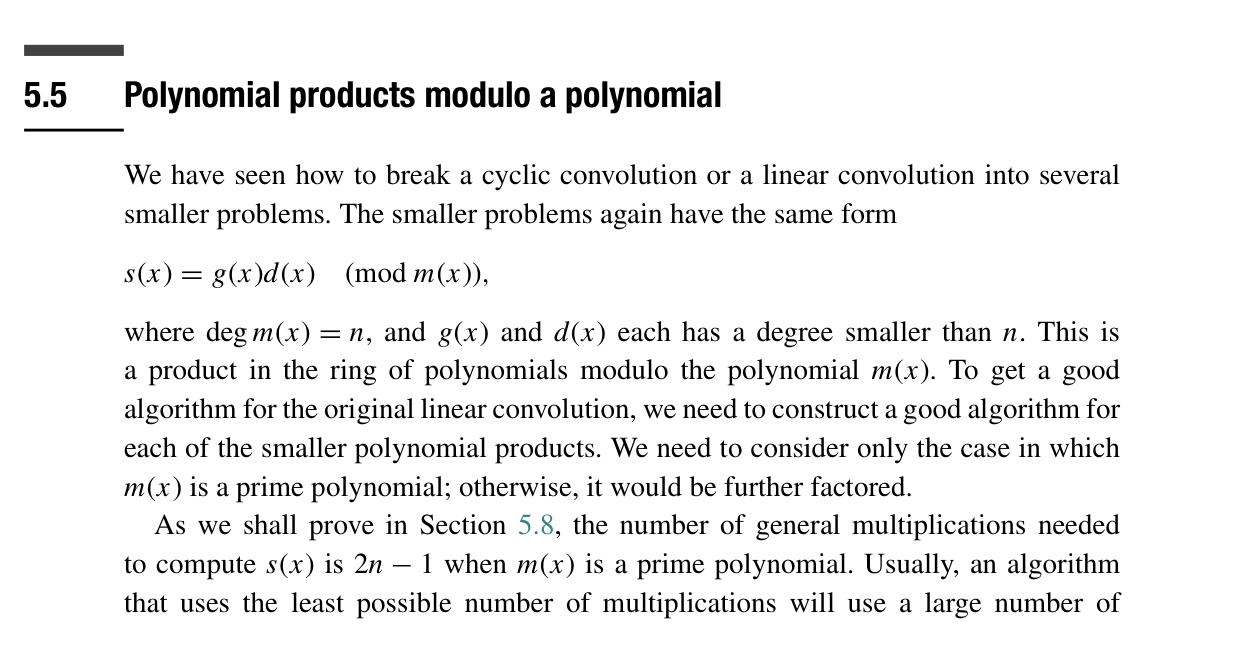

In [5]:
plot_pdf(doc[183], [.6, .95])

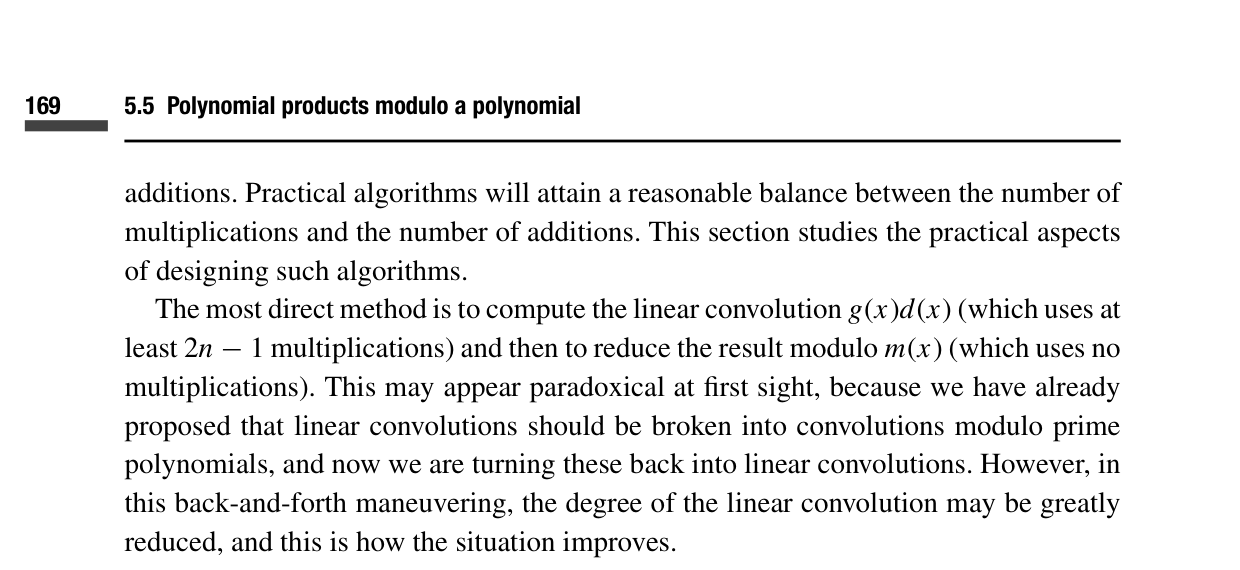

In [6]:
plot_pdf(doc[184], [0, .3])

Size of vectors

In [7]:
d_num = 3
g_num = 3

Example of vectors for the convolution

In [8]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [9]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [10]:
x = sy.symbols("x")
x

x

In [11]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2]])

In [12]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1],
[g_2]])

In [13]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2

In [14]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2

In [15]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2)*(g_0 + g_1*x + g_2*x**2)

In [16]:
sx.expand().collect(x)

d_0*g_0 + d_2*g_2*x**4 + x**3*(d_1*g_2 + d_2*g_1) + x**2*(d_0*g_2 + d_1*g_1 + d_2*g_0) + x*(d_0*g_1 + d_1*g_0)

In [17]:
sum(gi)*sum(di)

(d_0 + d_1 + d_2)*(g_0 + g_1 + g_2)

In [18]:
conv = np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1))
sy.Matrix(conv)

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1],
[                    d_2*g_2]])

In [21]:
s0 = [symmetrical_polynomial_factorization(i, di, gi) for i in conv[1:-1]]
si = sy.Matrix([conv[0]] + s0 + [conv[-1]])
si

Matrix([
[                                               d_0*g_0],
[          -d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)],
[-d_0*g_0 + d_1*g_1 - d_2*g_2 + (d_0 + d_2)*(g_0 + g_2)],
[          -d_1*g_1 - d_2*g_2 + (d_1 + d_2)*(g_1 + g_2)],
[                                               d_2*g_2]])

In [22]:
sx = sum([i*x**e for e, i in enumerate(si)])
sx.collect(x)

d_0*g_0 + d_2*g_2*x**4 + x**3*(-d_1*g_1 - d_2*g_2 + (d_1 + d_2)*(g_1 + g_2)) + x**2*(-d_0*g_0 + d_1*g_1 - d_2*g_2 + (d_0 + d_2)*(g_0 + g_2)) + x*(-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1))

In [23]:
sx0 = sx.subs({x**4: -1})
sx0

d_0*g_0 - d_2*g_2 + x**3*(-d_1*g_1 - d_2*g_2 + (d_1 + d_2)*(g_1 + g_2)) + x**2*(-d_0*g_0 + d_1*g_1 - d_2*g_2 + (d_0 + d_2)*(g_0 + g_2)) + x*(-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1))

In [28]:
sy.degree(sx, x)

4

In [29]:
sx0_args = sorted(
    (dict.fromkeys((-1)*a if str(a).startswith("-") else a  for d in range(sy.degree(sx, x)+1) for a in sx0.coeff(x, d).args)),
    key=lambda i: len(str(i))
)
sy.Matrix(sx0_args)

Matrix([
[                d_0*g_0],
[                d_2*g_2],
[                d_1*g_1],
[(d_0 + d_1)*(g_0 + g_1)],
[(d_0 + d_2)*(g_0 + g_2)],
[(d_1 + d_2)*(g_1 + g_2)]])

In [30]:
sx0_list_ = [sum(sx0.coeff(x, d).args)  for d in range(sy.degree(sx, x)+1)]
sx0_list = [s for s in sx0_list_ if s != 0]
sy.Matrix(sx0_list)

Matrix([
[                                     d_0*g_0 - d_2*g_2],
[          -d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)],
[-d_0*g_0 + d_1*g_1 - d_2*g_2 + (d_0 + d_2)*(g_0 + g_2)],
[          -d_1*g_1 - d_2*g_2 + (d_1 + d_2)*(g_1 + g_2)]])

In [31]:
a_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in di] for s in sy.Matrix(sx0_args).expand()])
a_mtx.tolist()

[[1, 0, 0], [0, 0, 1], [0, 1, 0], [1, 1, 0], [1, 0, 1], [0, 1, 1]]

In [32]:
b_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in gi] for s in sy.Matrix(sx0_args).expand()])
b_mtx.tolist()


[[1, 0, 0], [0, 0, 1], [0, 1, 0], [1, 1, 0], [1, 0, 1], [0, 1, 1]]

In [33]:
bg_mtx = sy.diag(*(b_mtx * gi))
bg_mtx

Matrix([
[g_0,   0,   0,         0,         0,         0],
[  0, g_2,   0,         0,         0,         0],
[  0,   0, g_1,         0,         0,         0],
[  0,   0,   0, g_0 + g_1,         0,         0],
[  0,   0,   0,         0, g_0 + g_2,         0],
[  0,   0,   0,         0,         0, g_1 + g_2]])

In [34]:
c_mtx = sy.Matrix([[s.coeff(a, 1) for a in sx0_args] for s in sx0_list])
c_mtx

Matrix([
[ 1, -1,  0, 0, 0, 0],
[-1,  0, -1, 1, 0, 0],
[-1, -1,  1, 0, 1, 0],
[ 0, -1, -1, 0, 0, 1]])

In [35]:
s0 = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s0

Matrix([
[ 1, -1,  0, 0, 0, 0],
[-1,  0, -1, 1, 0, 0],
[-1, -1,  1, 0, 1, 0],
[ 0, -1, -1, 0, 0, 1]])*Matrix([
[g_0,   0,   0,         0,         0,         0],
[  0, g_2,   0,         0,         0,         0],
[  0,   0, g_1,         0,         0,         0],
[  0,   0,   0, g_0 + g_1,         0,         0],
[  0,   0,   0,         0, g_0 + g_2,         0],
[  0,   0,   0,         0,         0, g_1 + g_2]])*Matrix([
[1, 0, 0],
[0, 0, 1],
[0, 1, 0],
[1, 1, 0],
[1, 0, 1],
[0, 1, 1]])*Matrix([
[d_0],
[d_1],
[d_2]])

In [36]:
sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)

Matrix([
[          d_0*g_0 - d_2*g_2],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1]])

In [40]:
c_mtx.tolist()

[[1, -1, 0, 0, 0, 0],
 [-1, 0, -1, 1, 0, 0],
 [-1, -1, 1, 0, 1, 0],
 [0, -1, -1, 0, 0, 1]]